In [1]:
!pip install tensorflow openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os

In [2]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [3]:
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
data_folder   = r"/content"
output_folder = r"/content"

os.makedirs(output_folder, exist_ok=True)

files = glob.glob(os.path.join(data_folder, "RevenueCenter_*.xlsx"))

In [5]:
# Error matrix
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

In [6]:
def create_sequences(series, window=30):
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    return np.array(X), np.array(y)


Processing: RevenueCenter_5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


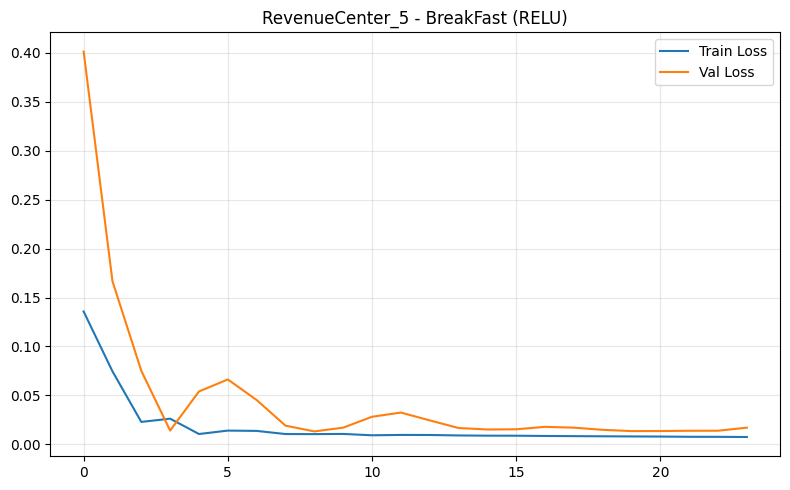

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step


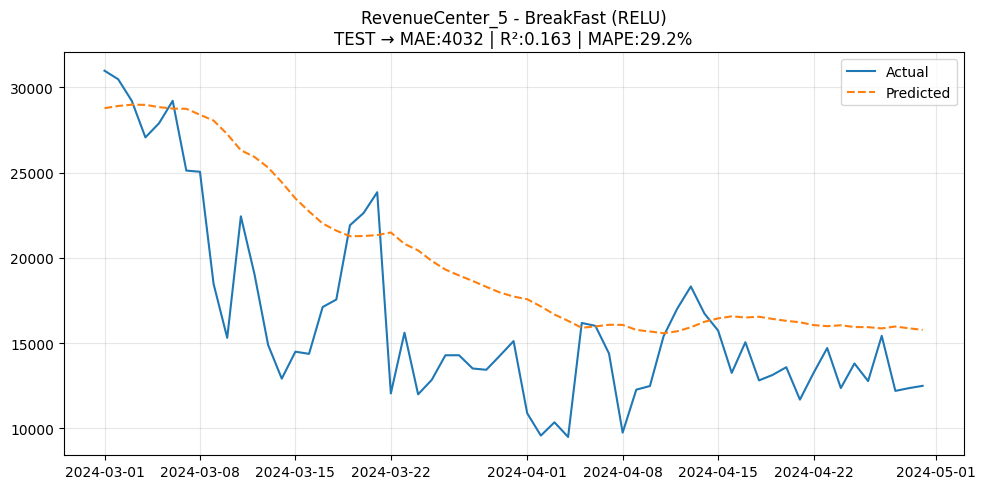

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


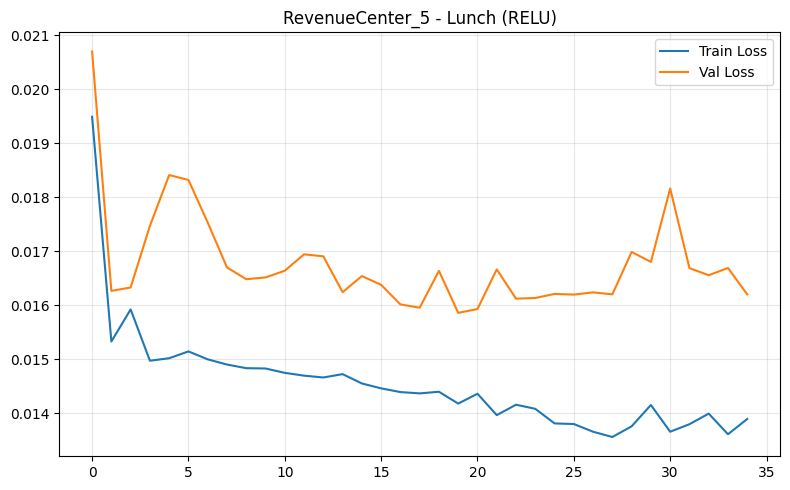

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step


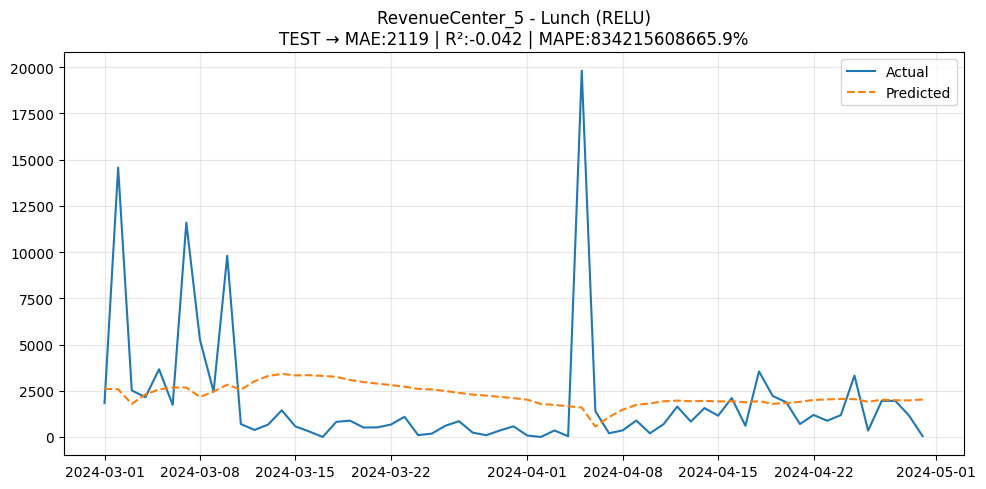

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


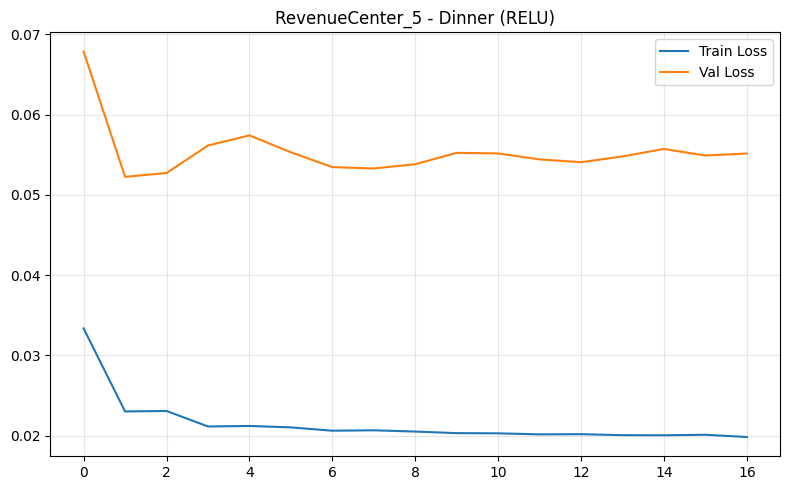

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step


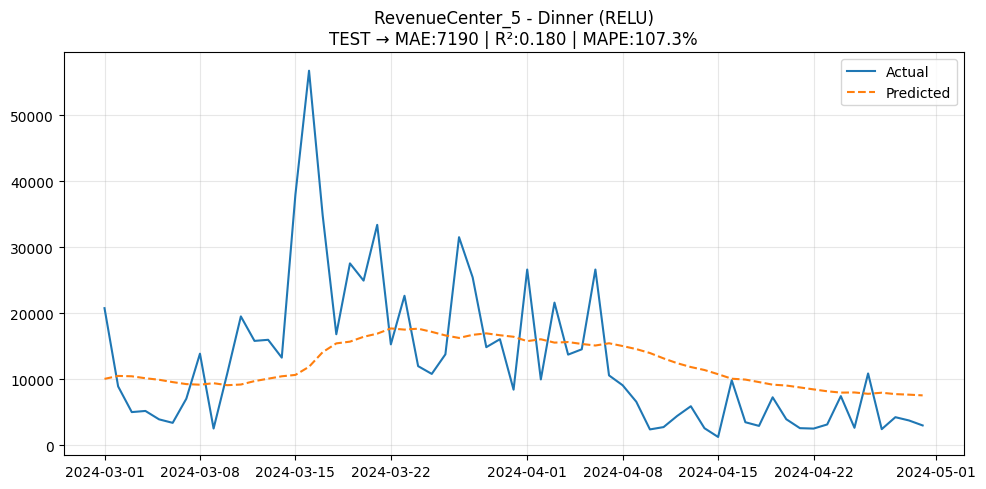

Saved: /content/RevenueCenter_5

Processing: RevenueCenter_7


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


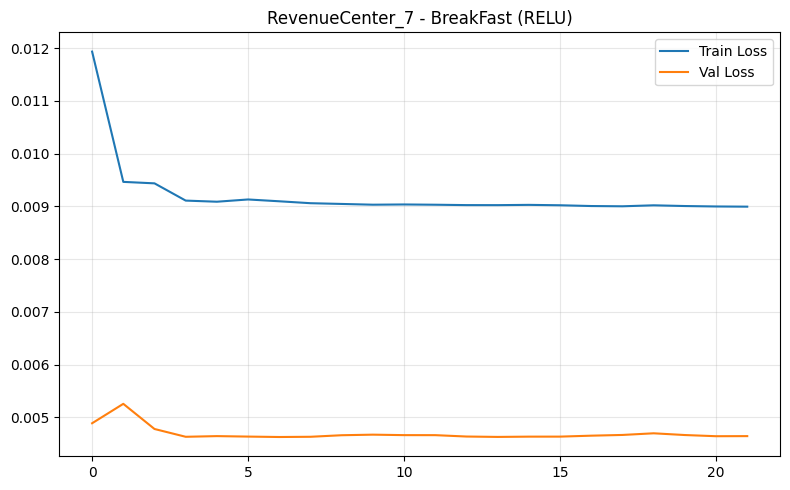

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step


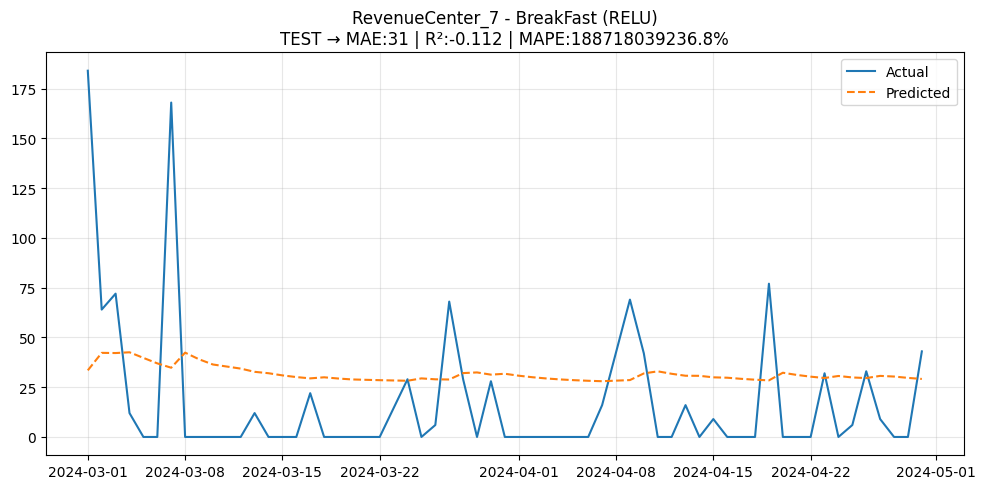

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


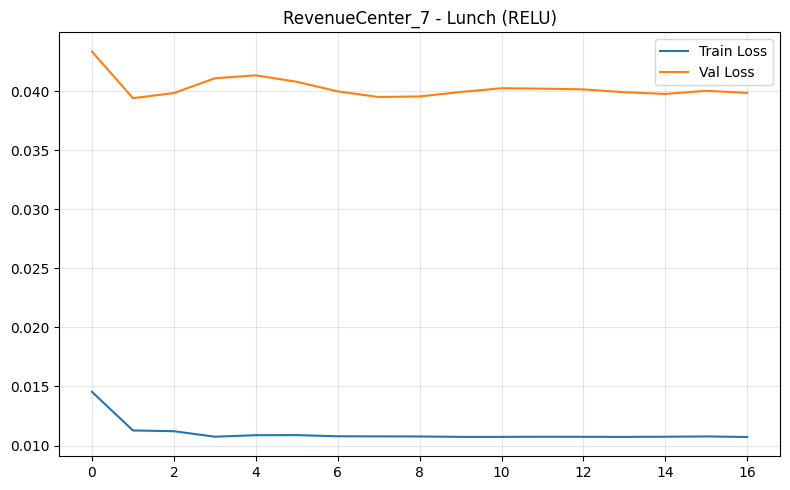

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 576ms/step


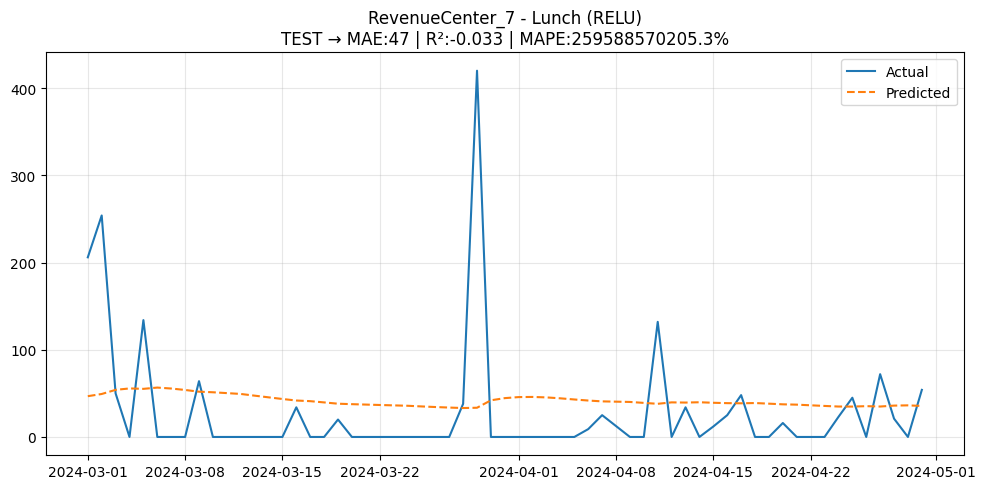

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


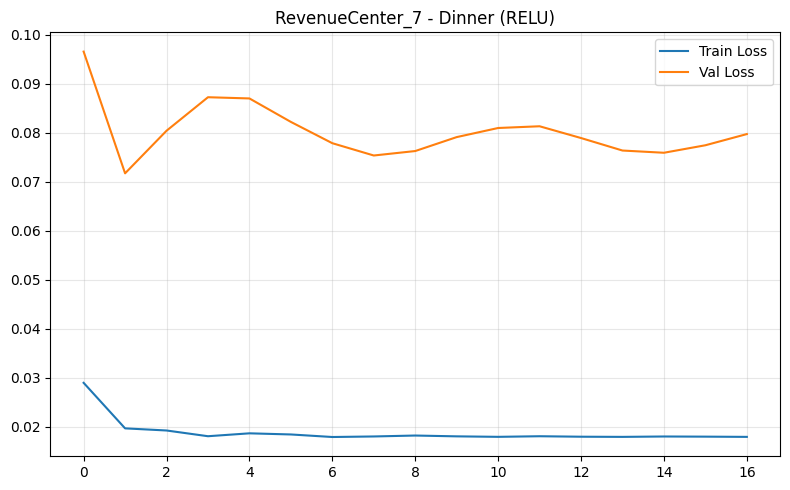

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step


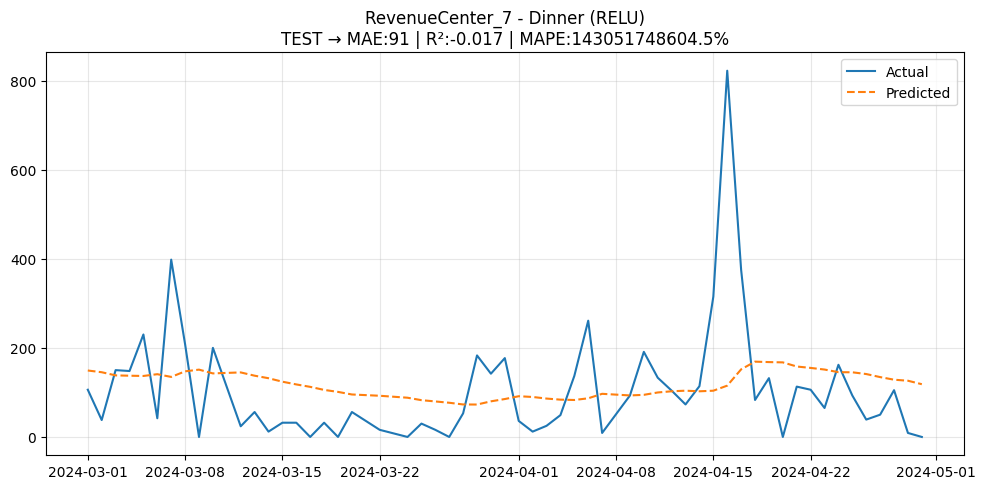

Saved: /content/RevenueCenter_7

Processing: RevenueCenter_2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


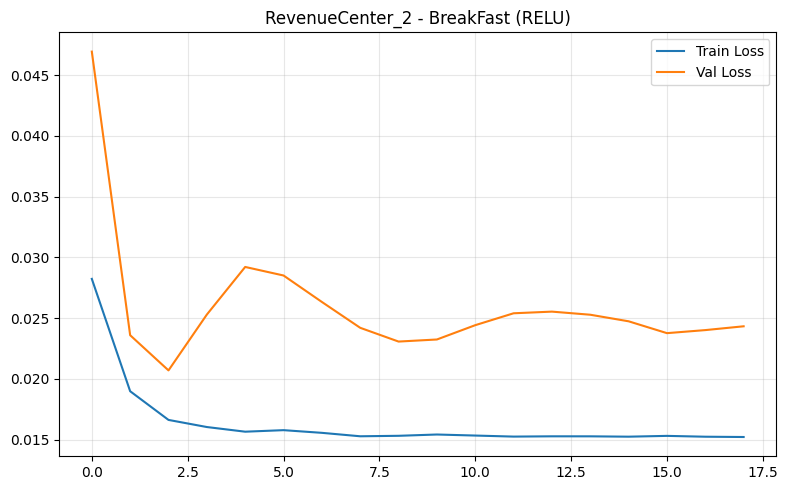

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step


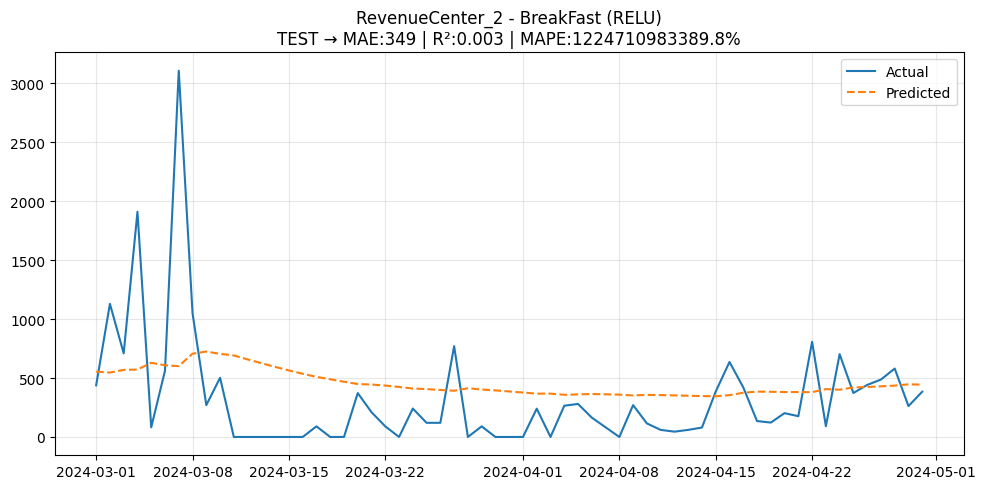

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


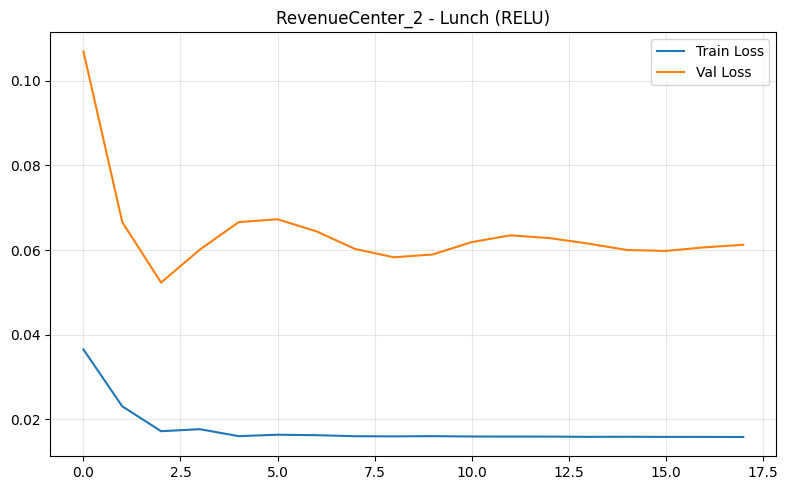

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step


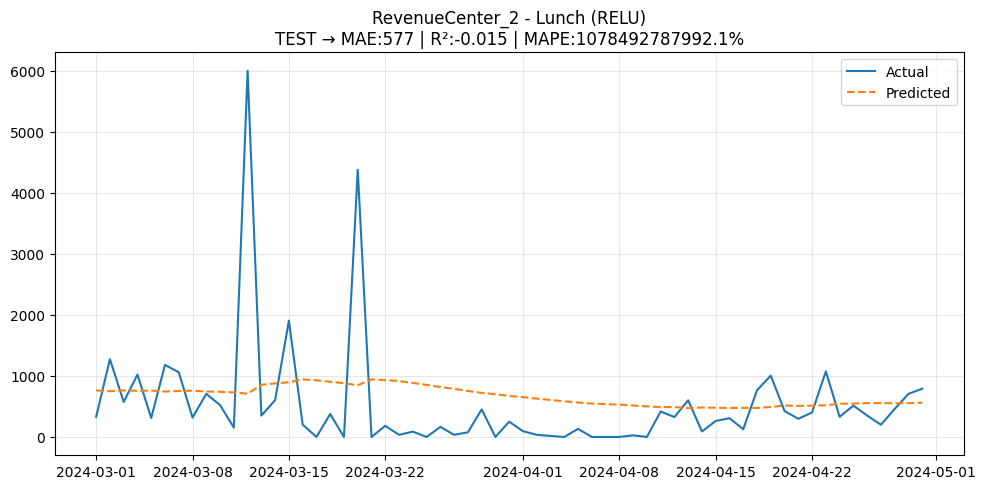

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


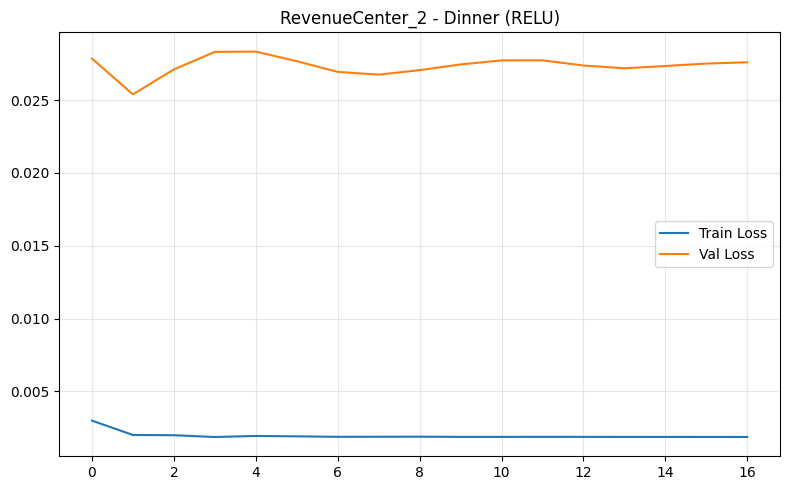

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step


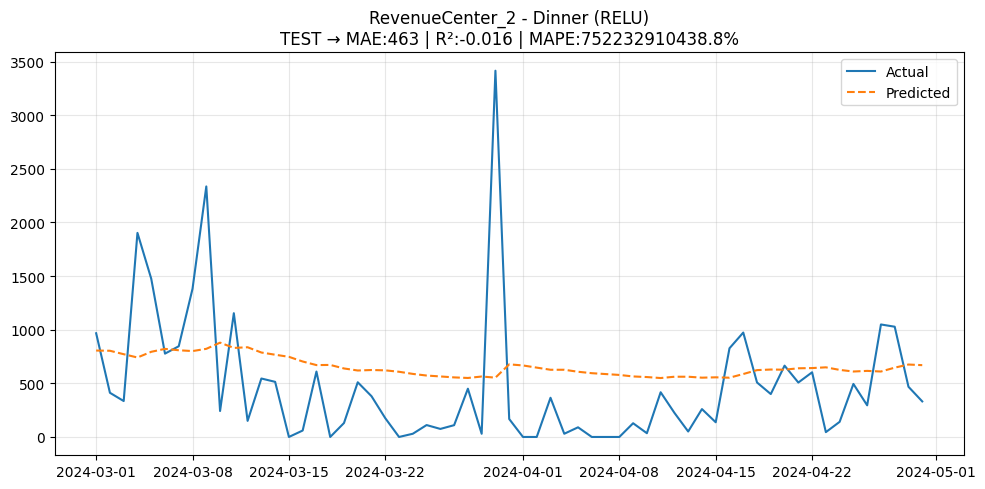

Saved: /content/RevenueCenter_2

Processing: RevenueCenter_1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


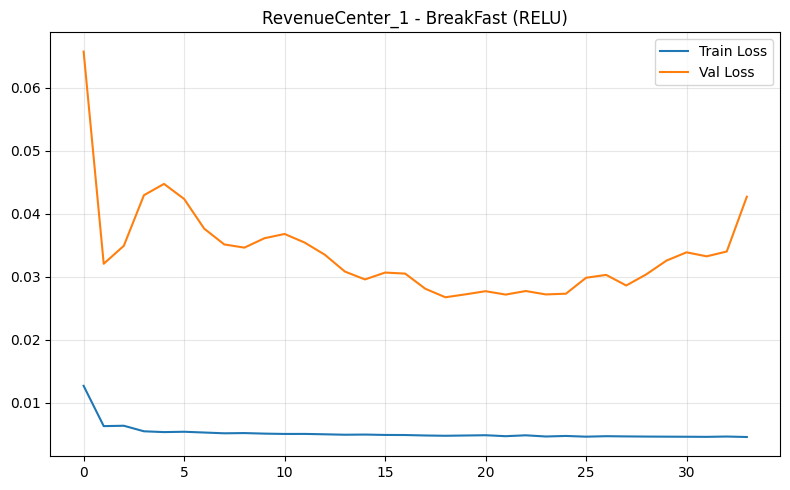

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step


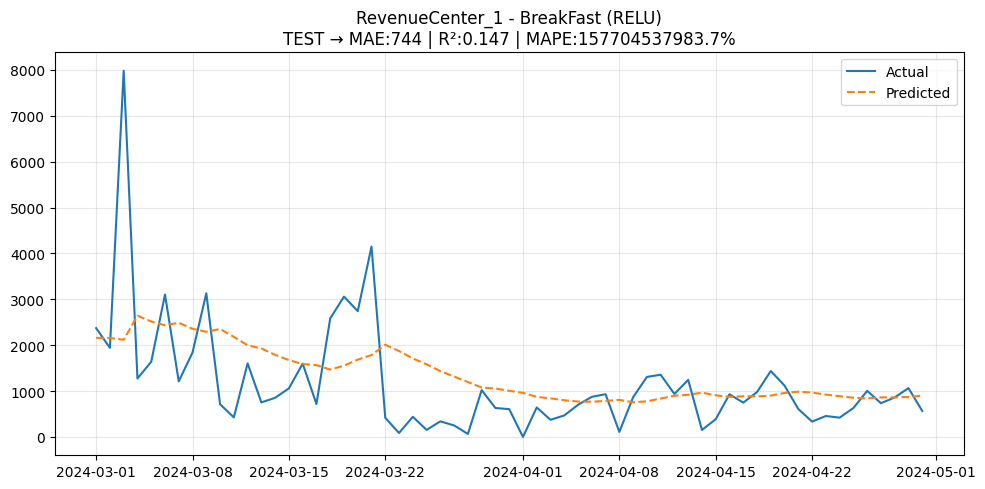

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


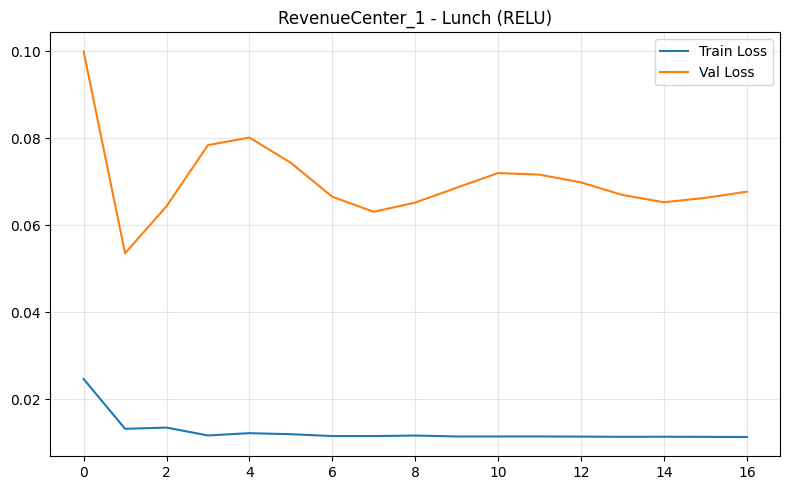

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 552ms/step


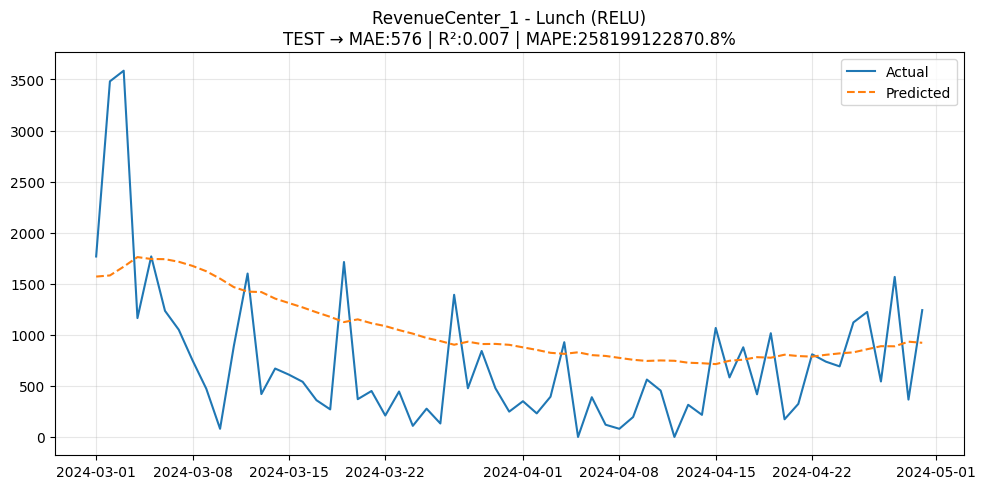

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


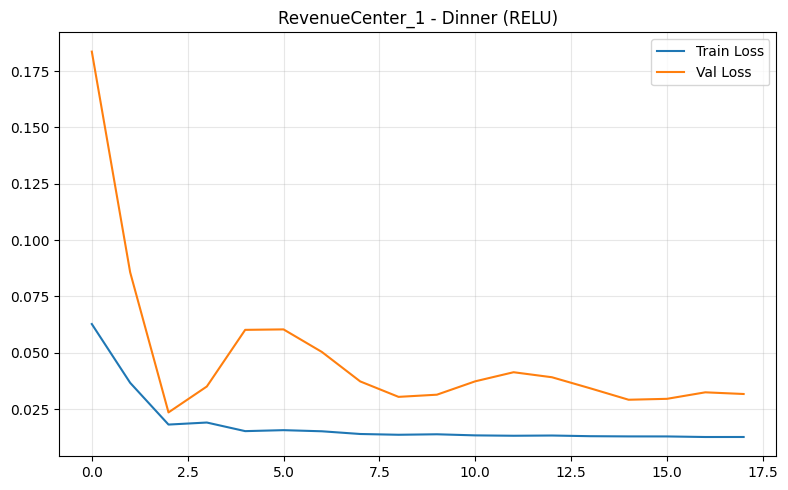

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step


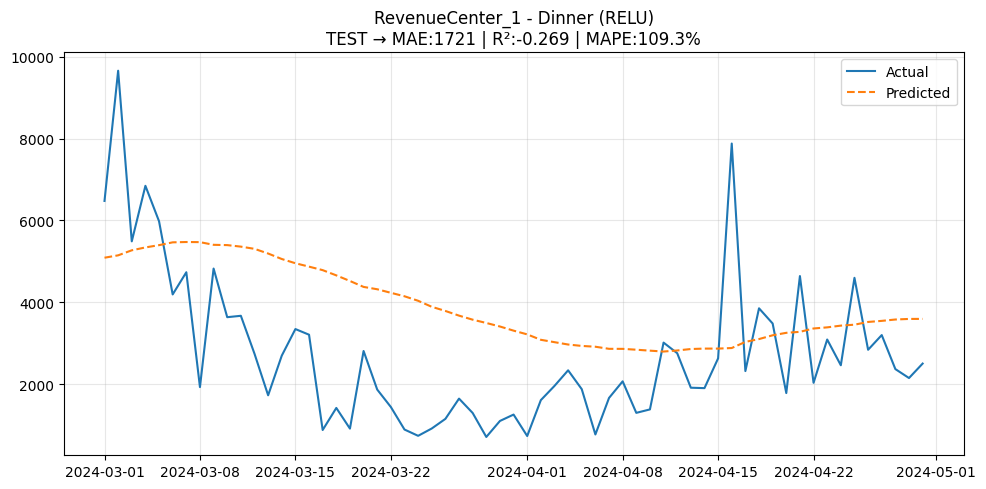

Saved: /content/RevenueCenter_1

Processing: RevenueCenter_6


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


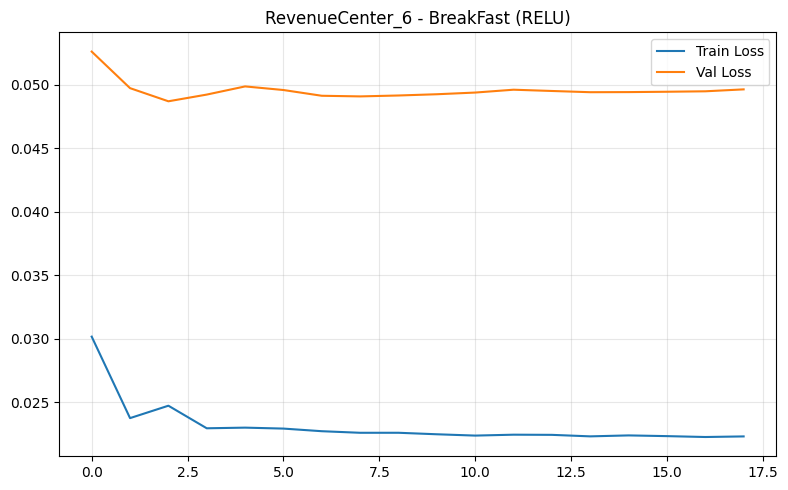

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step


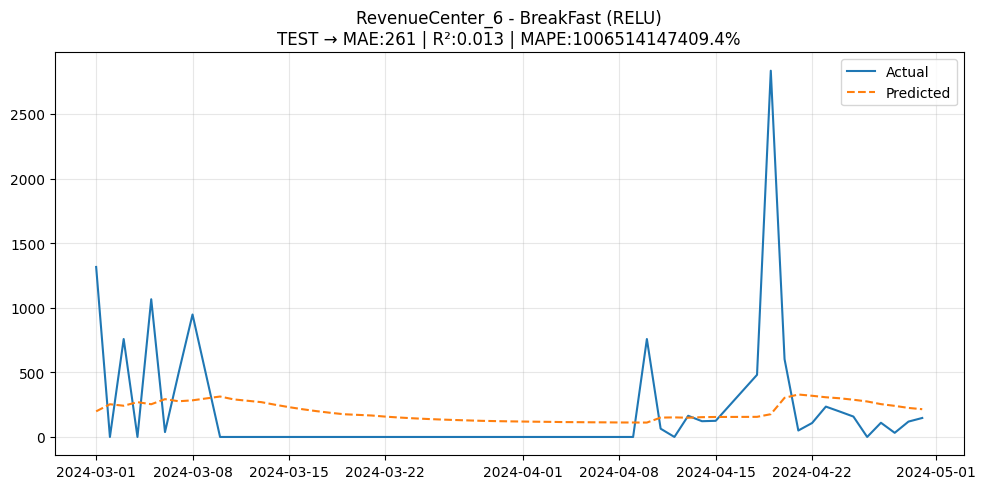

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


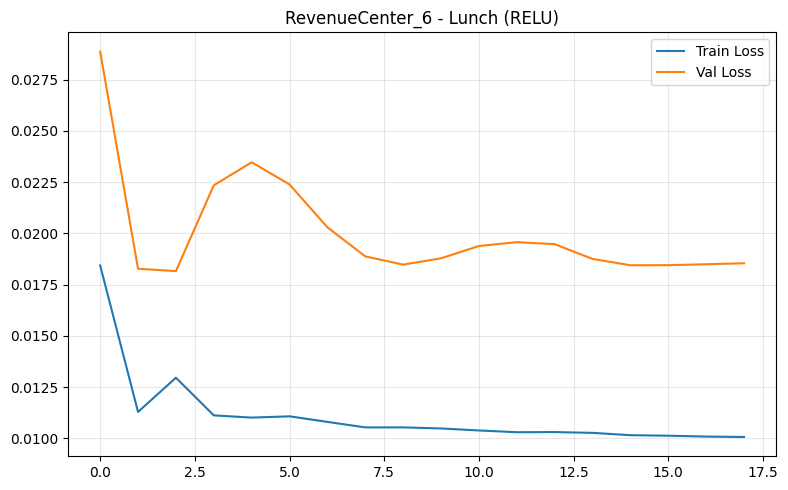

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step


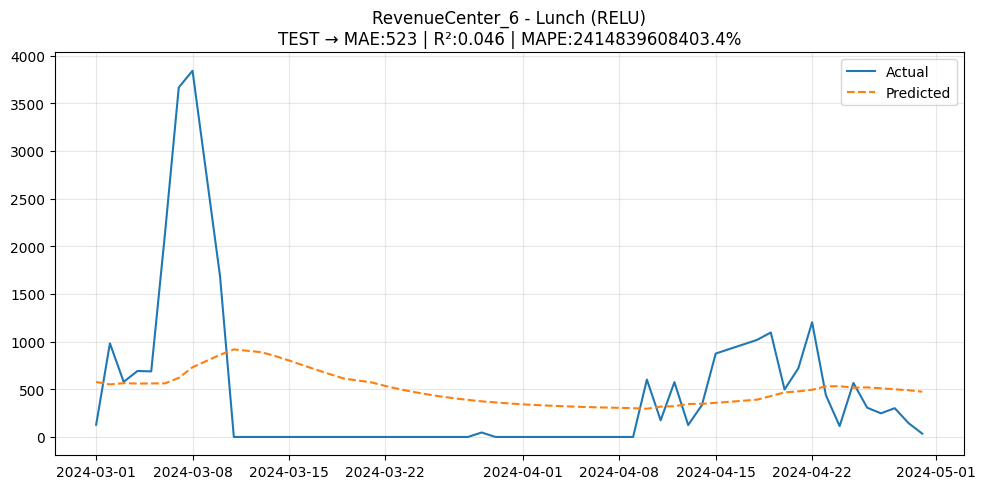

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


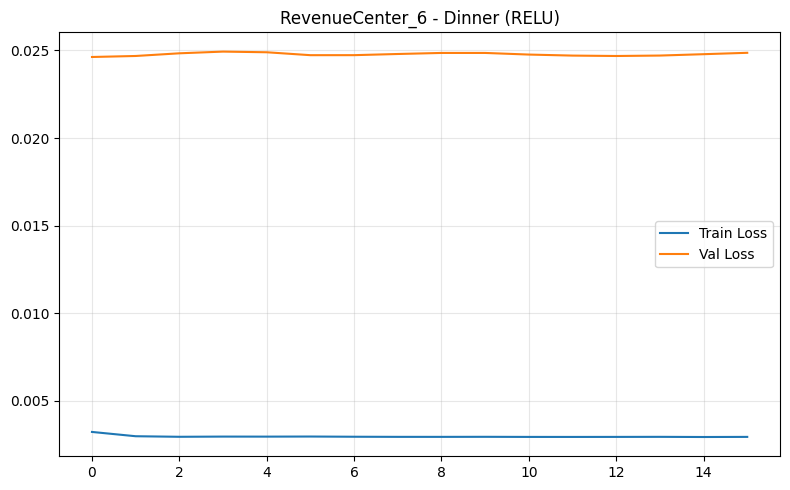

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step


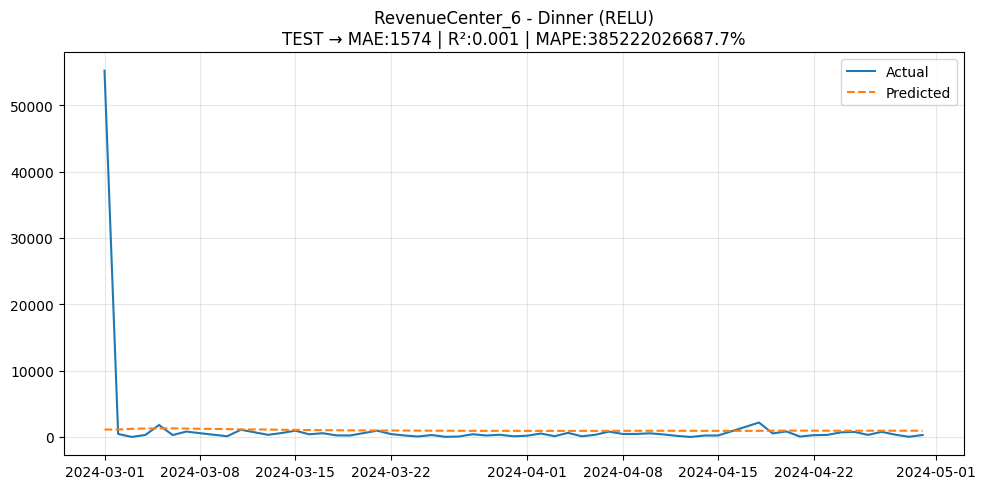

Saved: /content/RevenueCenter_6

Processing: RevenueCenter_4


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


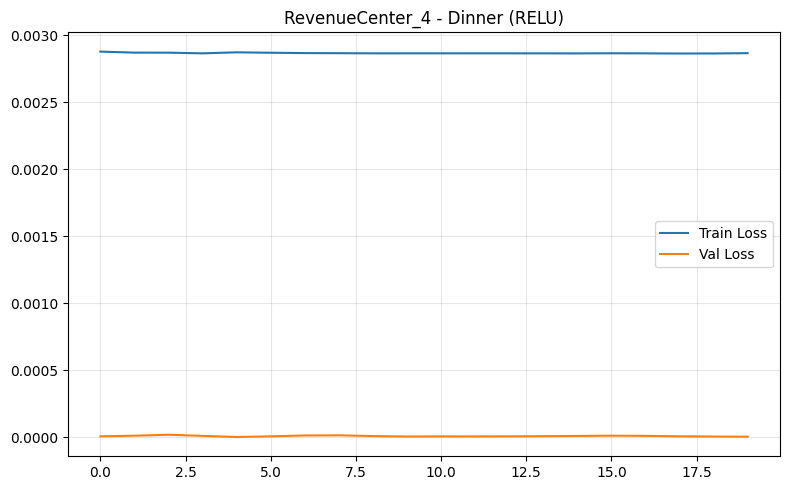

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step


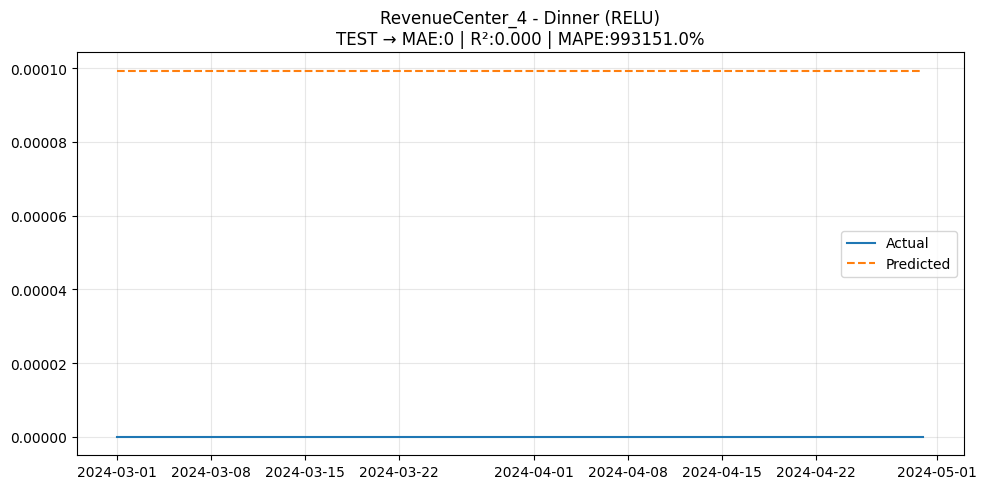

Saved: /content/RevenueCenter_4

Processing: RevenueCenter_8


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


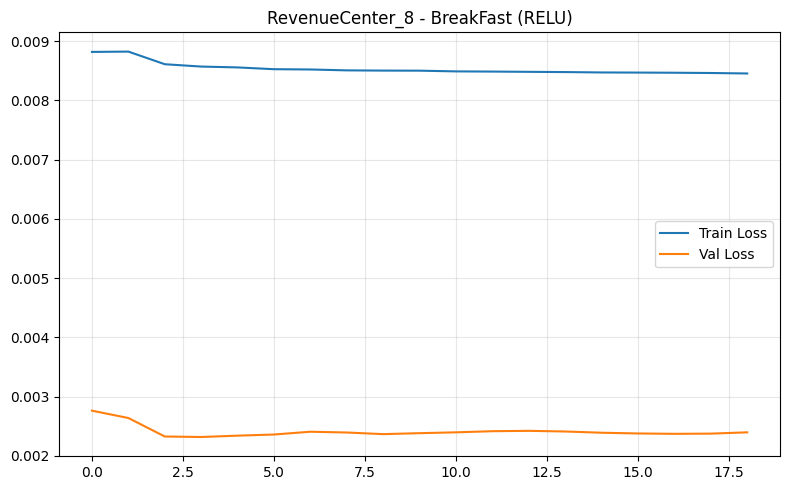

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step


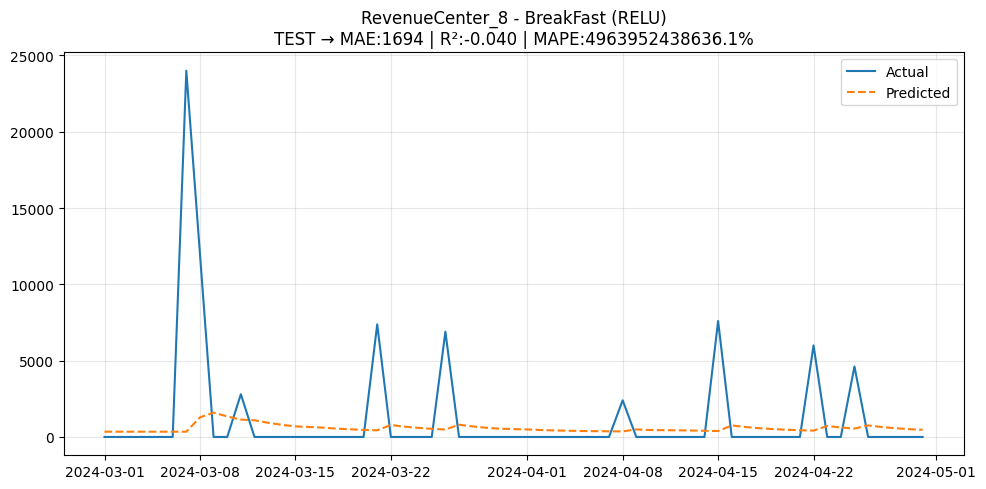

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


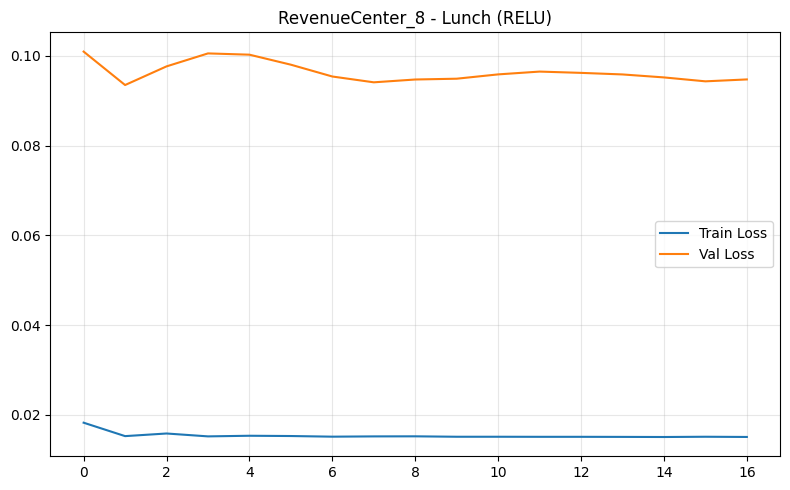

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step


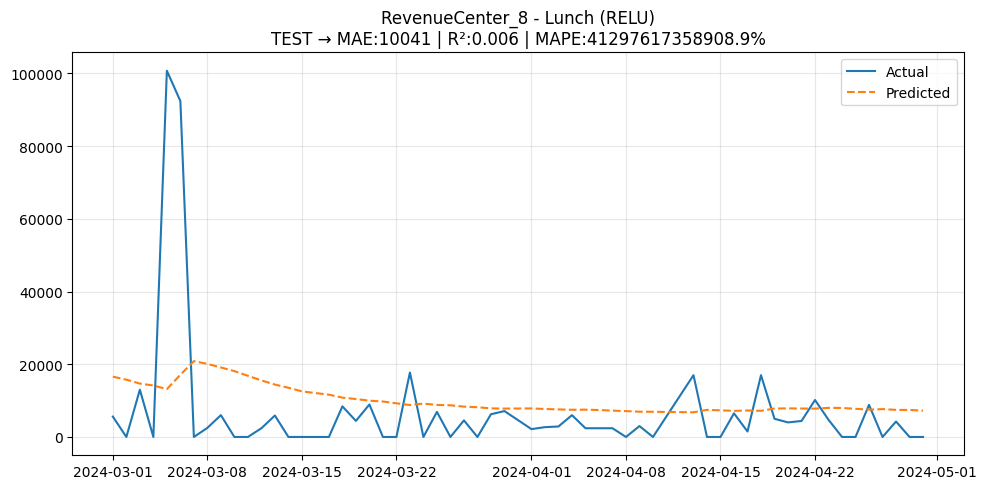

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


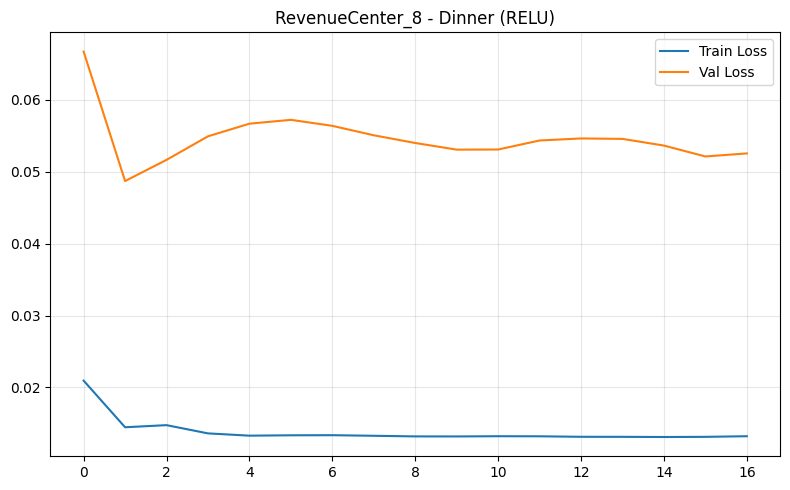

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step


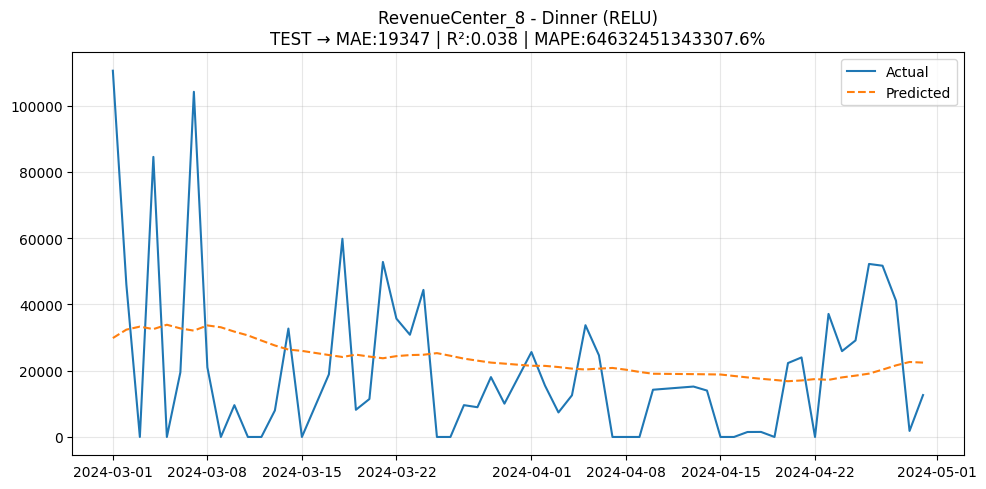

Saved: /content/RevenueCenter_8

Processing: RevenueCenter_3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


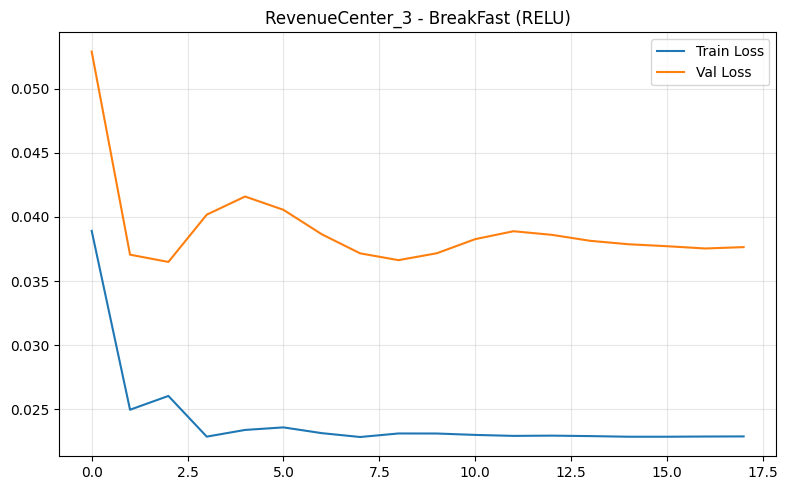

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step


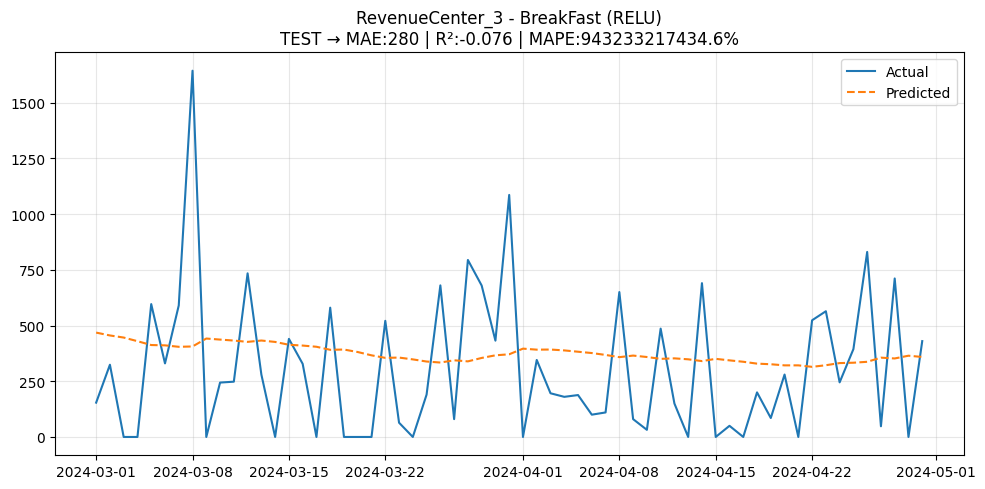

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


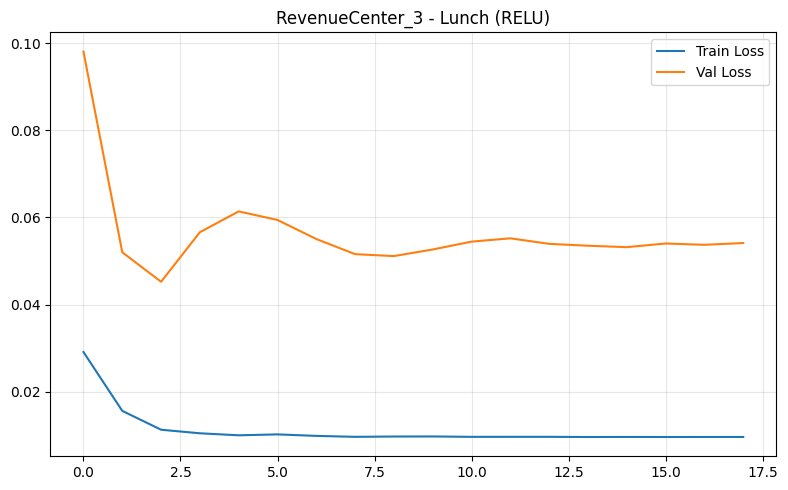

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step


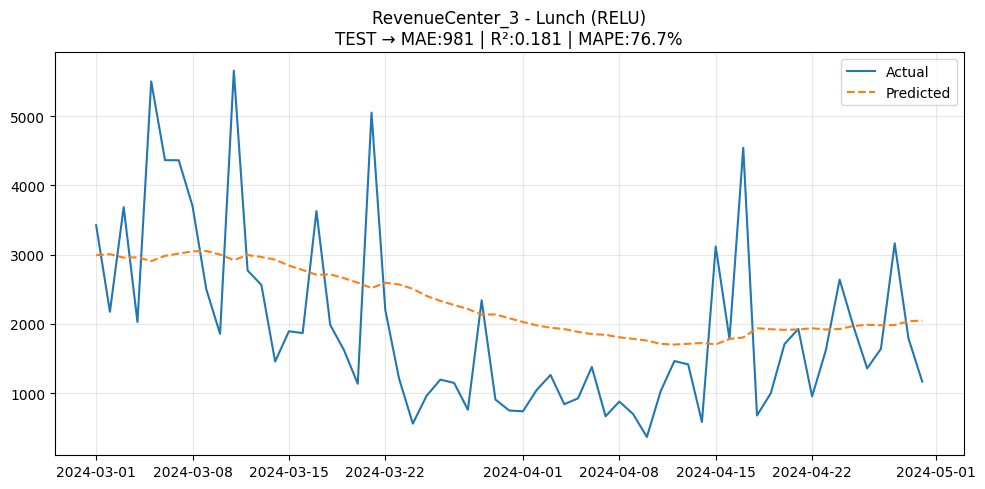

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


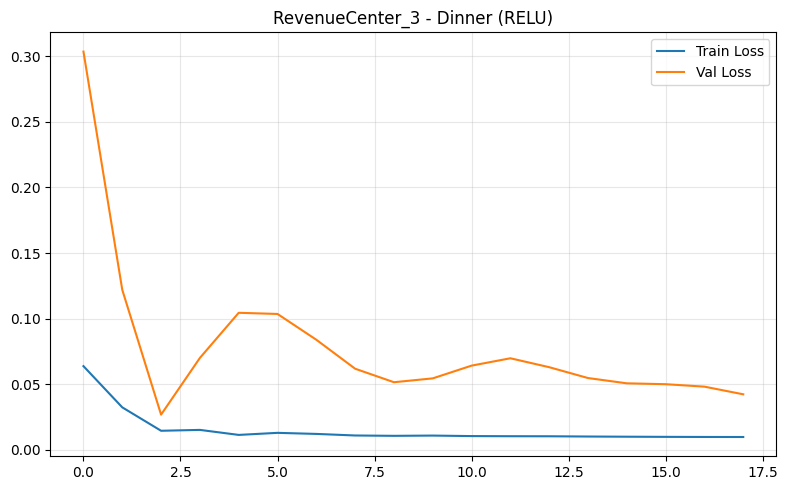

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step


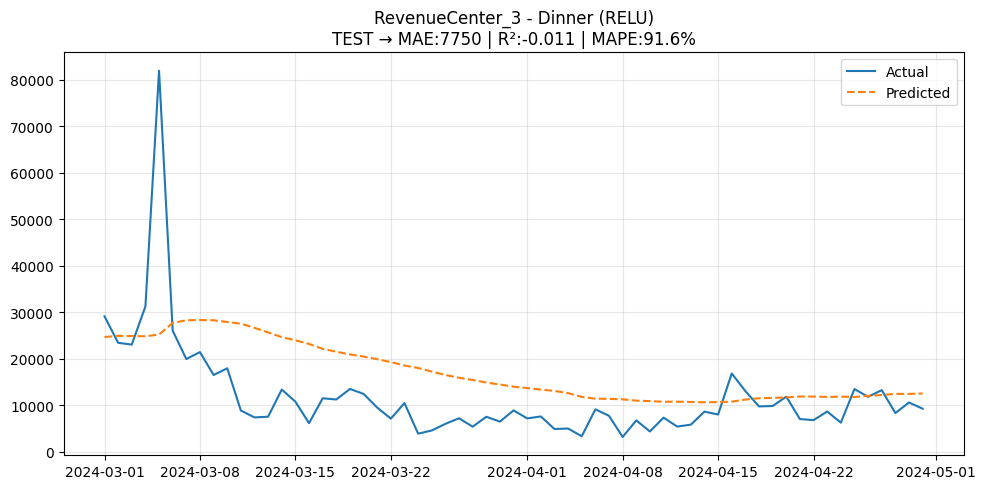

Saved: /content/RevenueCenter_3

Processing: RevenueCenter_9


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


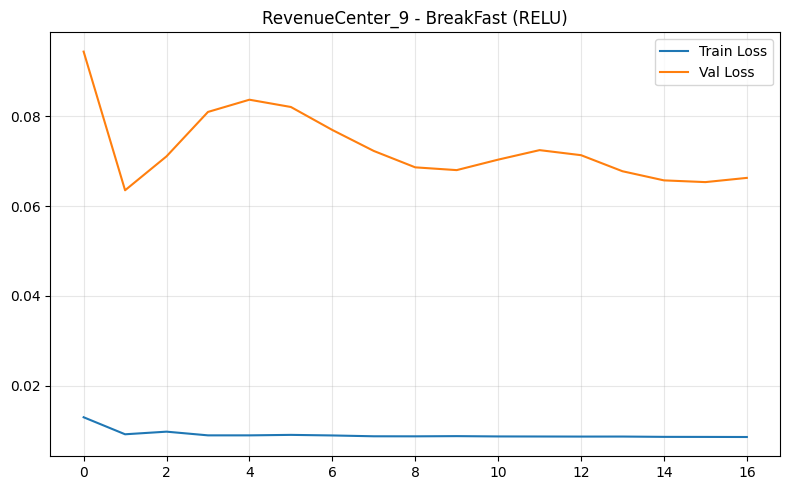

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step


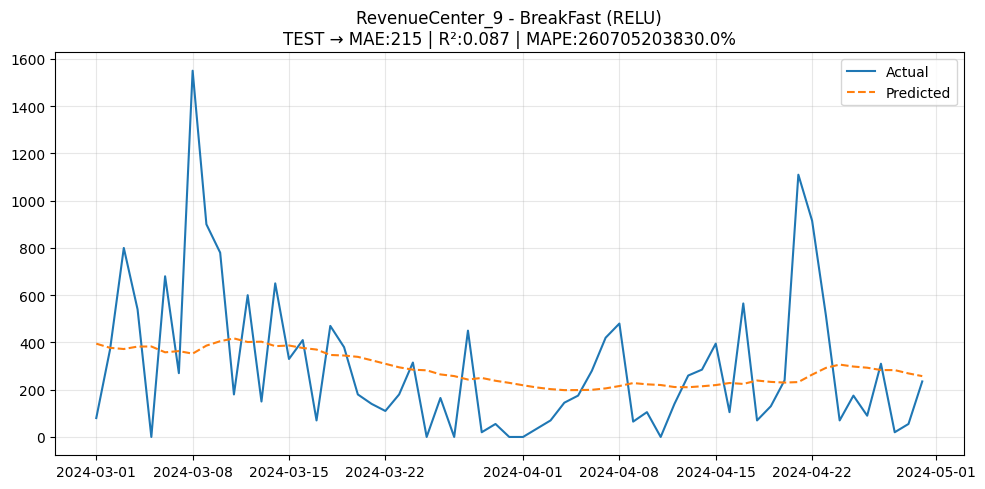

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


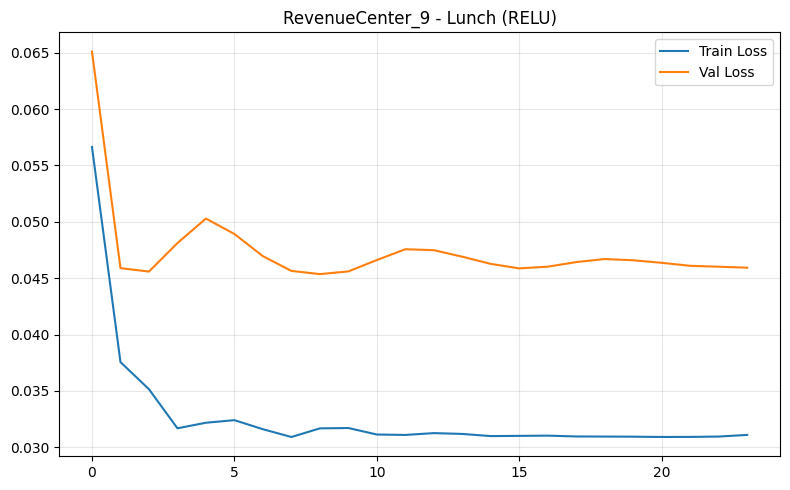

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step


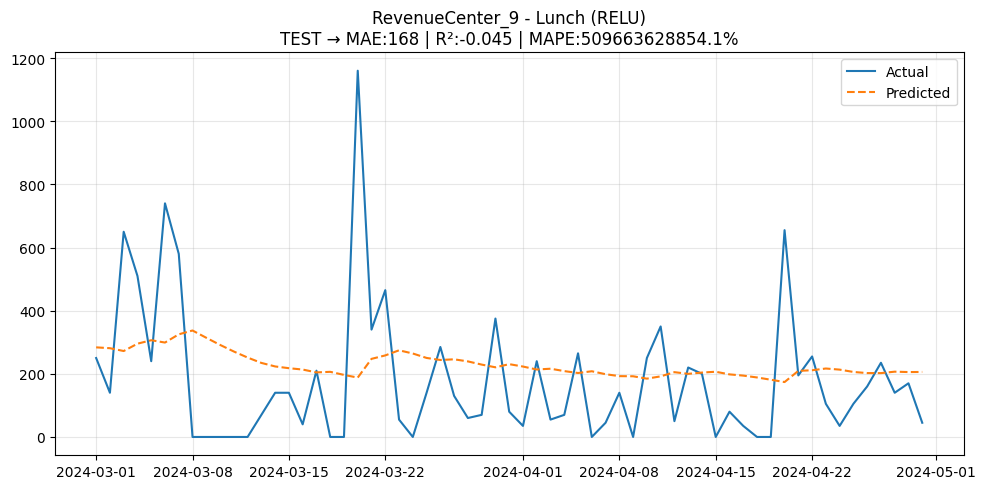

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


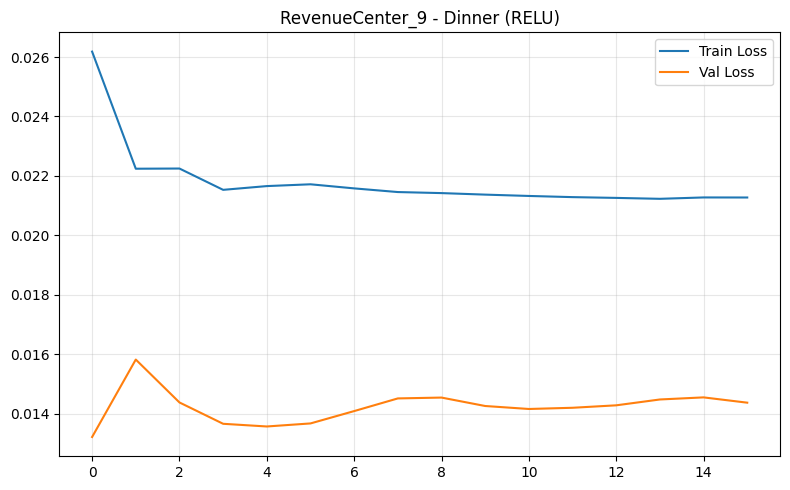

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step


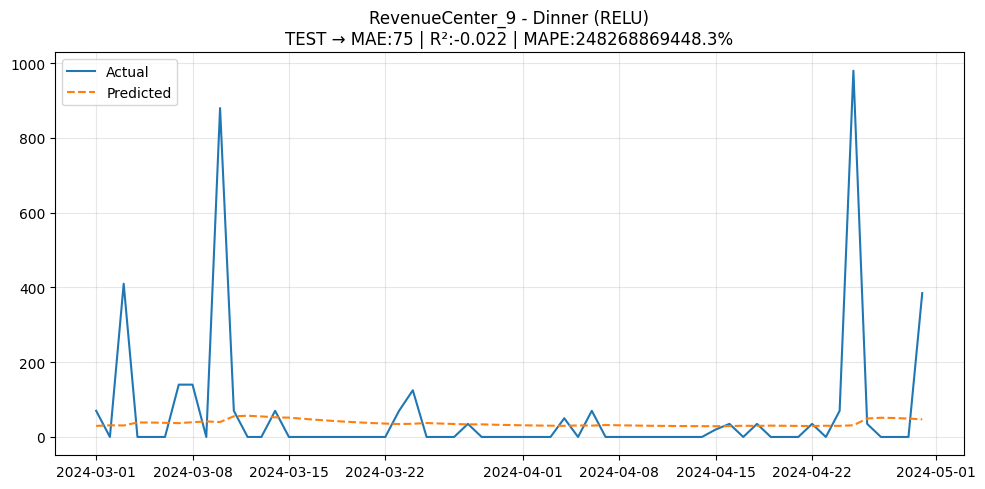

Saved: /content/RevenueCenter_9

ALL CENTERS COMPLETED — RELU MODEL


In [11]:
for file in files:

    center_name = os.path.basename(file).replace(".xlsx", "")
    print("\nProcessing:", center_name)

    center_path = os.path.join(output_folder, center_name)
    os.makedirs(center_path, exist_ok=True)

    df = pd.read_excel(file)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    split_date = df["Date"].max() - pd.DateOffset(months=2)
    meals = ["BreakFast", "Lunch", "Dinner"]

    for meal in meals:

        temp_df = df[["Date", meal]].copy()
        temp_df.rename(columns={meal: "y"}, inplace=True)

        train_df = temp_df[temp_df["Date"] <= split_date]
        test_df  = temp_df[temp_df["Date"] > split_date]

        if train_df["y"].nunique() <= 1:
            continue

        scaler = MinMaxScaler()
        train_scaled = scaler.fit_transform(train_df[["y"]])
        test_scaled  = scaler.transform(test_df[["y"]])

        WINDOW = 30
        X_train, y_train = create_sequences(train_scaled, WINDOW)
        combined = np.vstack([train_scaled[-WINDOW:], test_scaled])
        X_test, y_test = create_sequences(combined, WINDOW)

        X_train = X_train.reshape(-1, WINDOW, 1)
        X_test  = X_test.reshape(-1, WINDOW, 1)

        # =========================
        # MODEL — RELU
        # =========================
        model = Sequential([
            LSTM(
                256,
                activation="relu",
                recurrent_activation="sigmoid",
                input_shape=(WINDOW, 1)
            ),
            Dense(1)
        ])

        model.compile(optimizer="adam", loss="mse")

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True
        )

        history = model.fit(
            X_train, y_train,
            epochs=300,
            batch_size=128,
            validation_split=0.1,
            callbacks=[early_stop],
            verbose=0
        )

        # =========================
        # LOSS PLOT
        # =========================
        plt.figure(figsize=(8,5))
        plt.plot(history.history["loss"], label="Train Loss")
        plt.plot(history.history["val_loss"], label="Val Loss")
        plt.title(f"{center_name} - {meal} (RELU)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(center_path, f"{meal}_loss_relu.png"), dpi=300)
        plt.show()
        plt.close()

        # =========================
        # PREDICTIONS
        # =========================
        y_train_pred = scaler.inverse_transform(model.predict(X_train))
        y_test_pred  = scaler.inverse_transform(model.predict(X_test))
        y_train_true = scaler.inverse_transform(y_train.reshape(-1,1))
        y_test_true  = scaler.inverse_transform(y_test.reshape(-1,1))

        train_mae  = mean_absolute_error(y_train_true, y_train_pred)
        train_r2   = r2_score(y_train_true, y_train_pred)
        train_mape = mape(y_train_true, y_train_pred)

        test_mae  = mean_absolute_error(y_test_true, y_test_pred)
        test_r2   = r2_score(y_test_true, y_test_pred)
        test_mape = mape(y_test_true, y_test_pred)

        plt.figure(figsize=(10,5))
        plt.plot(test_df["Date"], y_test_true, label="Actual")
        plt.plot(test_df["Date"], y_test_pred, "--", label="Predicted")
        plt.title(
            f"{center_name} - {meal} (RELU)\n"
            f"TEST → MAE:{test_mae:.0f} | R²:{test_r2:.3f} | MAPE:{test_mape:.1f}%"
        )
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(center_path, f"{meal}_pred_tanh.png"), dpi=300)
        plt.show()
        plt.close()

    print("Saved:", center_path)

print("\nALL CENTERS COMPLETED — RELU MODEL")